# Observe the data and look at class imbalance

In [1]:
# imports
import os
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

In [2]:
# reference training images folder:
train_images_folder = "Data/Training/Training_Images"

# reference csv:
train_csv = "Data/Training/Training_LabelsDemographic.csv"
# load in csv:
train_df = pd.read_csv(train_csv)

# csv columns: 'image', 'myopic_maculopathy_grade', 'age', 'sex', 'height', 'weight', 'data_center'
print("train_csv columns: ", train_df.columns)

# head
print("train_df head: ")
print(train_df.head())

train_csv columns:  Index(['image', 'myopic_maculopathy_grade', 'age', 'sex', 'height', 'weight',
       'data_center'],
      dtype='str')
train_df head: 
                        image  myopic_maculopathy_grade  age   sex  height  \
0  mmac_task_1_train_0001.png                         0   51  male   183.5   
1  mmac_task_1_train_0002.png                         0   51  male   183.5   
2  mmac_task_1_train_0003.png                         0   50  male   184.5   
3  mmac_task_1_train_0004.png                         0   50  male   184.5   
4  mmac_task_1_train_0005.png                         0   49  male   184.5   

   weight  data_center  
0    78.9            1  
1    78.9            1  
2    81.7            1  
3    81.7            1  
4    82.2            1  


In [3]:
# show values in myopic_maculopathy_grade
print("myopic_maculopathy_grade values: ", train_df["myopic_maculopathy_grade"].unique())
# grade 0 to 4

myopic_maculopathy_grade values:  [0 1 2 3 4]


In [4]:
# determine class imbalance (count of each grade)
print("class imbalance: ")
print(train_df["myopic_maculopathy_grade"].value_counts())

class imbalance: 
myopic_maculopathy_grade
1    412
0    404
2    224
3     60
4     43
Name: count, dtype: int64


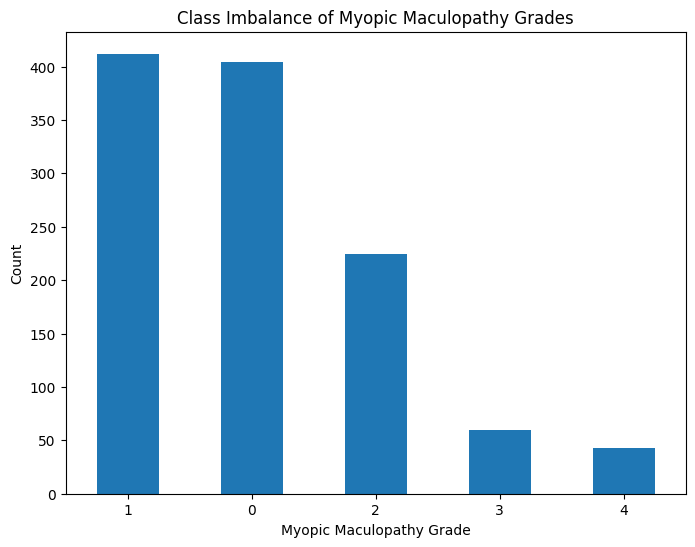

Grade 0: 404 images
Grade 1: 412 images
Grade 2: 224 images
Grade 3: 60 images
Grade 4: 43 images


In [5]:
# bar chart of class imbalance
plt.figure(figsize=(8, 6))
train_df["myopic_maculopathy_grade"].value_counts().plot(kind="bar")
plt.title("Class Imbalance of Myopic Maculopathy Grades")
plt.xlabel("Myopic Maculopathy Grade")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

# print number of images in each grade:
for grade in range(5):
    grade_count = train_df[train_df["myopic_maculopathy_grade"] == grade].shape[0]
    print(f"Grade {grade}: {grade_count} images")

Class 0 and 1 are fairly well balance - there are far less images with grade 2, 3 and 4.

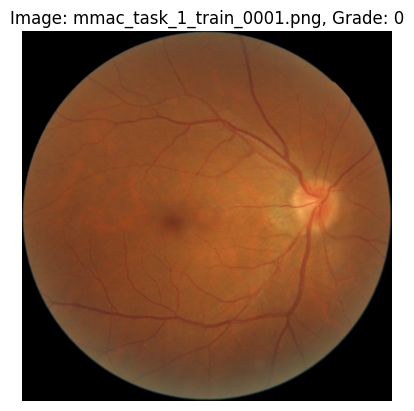

Image shape:  (800, 800)
Min pixel value:  (0, 0, 0)
Max pixel value:  (251, 163, 92)


/var/folders/q3/f8bspqwx7l54y8mwlwq7gq240000gn/T/ipykernel_98560/4050253628.py:12: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  print("Min pixel value: ", min(image.getdata()))
/var/folders/q3/f8bspqwx7l54y8mwlwq7gq240000gn/T/ipykernel_98560/4050253628.py:13: DeprecationWarning: Image.Image.getdata is deprecated and will be removed in Pillow 14 (2027-10-15). Use get_flattened_data instead.
  print("Max pixel value: ", max(image.getdata()))


In [6]:
# load an image and show it
image_path = os.path.join(train_images_folder, train_df["image"][0])

image = Image.open(image_path).convert("RGB") # matplotlib expects RGB, PIL loads RGBA, so we need to convert it first
plt.imshow(image)
plt.title(f"Image: {train_df['image'][0]}, Grade: {train_df['myopic_maculopathy_grade'][0]}")
plt.axis("off")
plt.show()

# print image shape and values:
print("Image shape: ", image.size)
print("Min pixel value: ", min(image.getdata()))
print("Max pixel value: ", max(image.getdata()))

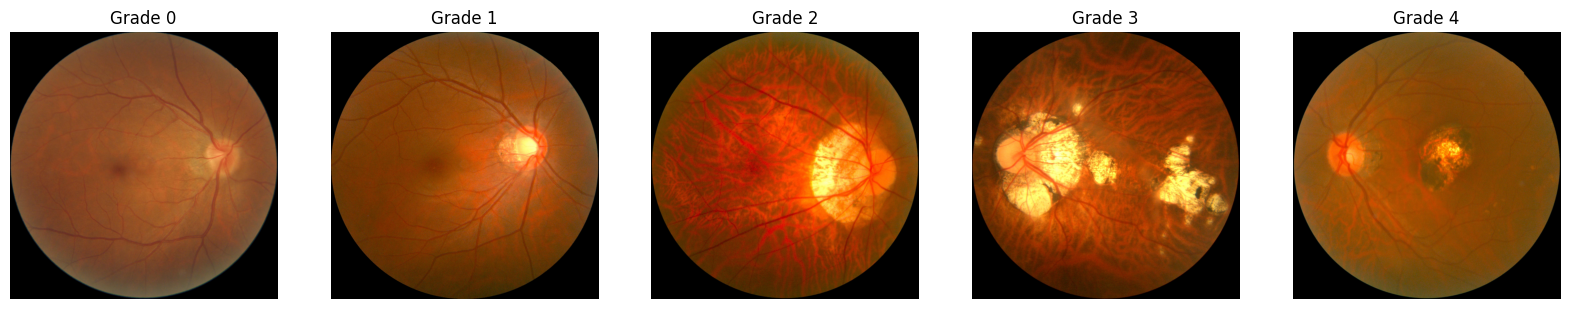

In [7]:
# view an example image from each class:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for grade in range(5):
    grade_image_path = os.path.join(train_images_folder, train_df[train_df["myopic_maculopathy_grade"] == grade]["image"].iloc[0]) # get first image path for this grade
    grade_image = Image.open(grade_image_path).convert("RGB") # to rgb
    
    axes[grade].imshow(grade_image)
    axes[grade].set_title(f"Grade {grade}")
    axes[grade].axis("off")
plt.show()

We can see that the optic nerve can be on either side of the image, so it is worth addressing this in data augmentation - i.e. we definitely need horizontal flip at minimum.

# Basic CNN classifier for myopic maculopathy:

#### Imports:

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
from tqdm import tqdm


# device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)


Using device: mps


#### Set up a custom dataset class and transformations for ease of use:

In [9]:
# define a custom dataset class for loading the images and labels
class MyopicMaculopathyDataset(Dataset):
    def __init__(self, csv_file, images_folder, transform=None):
        self.data = pd.read_csv(csv_file)
        self.images_folder = images_folder
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_name = os.path.join(self.images_folder, self.data.iloc[idx]["image"])
        image = Image.open(img_name).convert("RGB") # RGBA to RGB
        label = self.data.iloc[idx]["myopic_maculopathy_grade"] # corresponding 0-4 label
        if self.transform:
            image = self.transform(image) # apply transform
        return image, label



In [10]:
# define transformations for the images
# convert to grayscale, normalise to [0, 1] and resize to 224x224 for ResNet
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.Grayscale(num_output_channels=3), # convert to grayscale but keep 3 channels to be compatible with pretrained models
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]), # normalise to [-1, 1]

    # random flips, will make the model robust to left/right eye or up/down imaging
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
])

#### Dataloader + view some transformed images

In [11]:
# create dataset and dataloader
dataset = MyopicMaculopathyDataset(csv_file=train_csv, images_folder=train_images_folder, transform=transform)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)



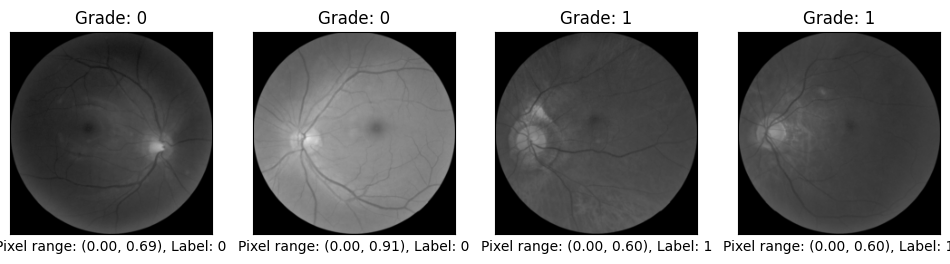

In [12]:
# visualise the transformed images
dataiter = iter(dataloader)
images, labels = next(dataiter)

# show a few transformed images
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for i in range(4):
    img = images[i].permute(1, 2, 0).numpy() # convert from (C, H, W) to (H, W, C) for plotting
    img = (img * 0.5) + 0.5 # un-normalise to [0, 1] for plotting
    axes[i].imshow(img)
    axes[i].set_title(f"Grade: {labels[i].item()}")

    # description:
    axes[i].set_xlabel(f"Pixel range: ({img.min():.2f}, {img.max():.2f}), Label: {labels[i].item()}")

    # no tickmarks:
    axes[i].set_xticks([])
    axes[i].set_yticks([])
plt.show()



#### Set up and train a model:

In [13]:
# now set up and train a ResNet model:
model = models.resnet18(pretrained=True) # load pretrained ResNet
# modify the final layer to output 5 classes (grades 0-4)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 5)
model = model.to(device) # move model weights to same device as inputs

# define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# training loop
num_epochs = 24
# use tqdm to show progress bar:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = images.to(device)
        labels = labels.to(device, dtype=torch.long)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    epoch_loss = running_loss / len(dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/24: 100%|██████████| 36/36 [00:20<00:00,  1.76it/s]


Epoch 1/24, Loss: 0.9624


Epoch 2/24: 100%|██████████| 36/36 [00:14<00:00,  2.53it/s]


Epoch 2/24, Loss: 0.6615


Epoch 3/24: 100%|██████████| 36/36 [00:14<00:00,  2.55it/s]


...

Epoch 22/24, Loss: 0.1771


Epoch 23/24: 100%|██████████| 36/36 [00:14<00:00,  2.54it/s]


Epoch 23/24, Loss: 0.2066


Epoch 24/24: 100%|██████████| 36/36 [00:14<00:00,  2.54it/s]

Epoch 24/24, Loss: 0.2102


#### Evaluate the model:

In [14]:
# get a prediction for some values in the training set and compare to the true label:
model.eval()
with torch.no_grad():
    images, labels = next(iter(dataloader))
    images = images.to(device)
    labels = labels.to(device, dtype=torch.long)
    outputs = model(images)
    _, preds = torch.max(outputs, 1)
    print("Predicted labels: ", preds)
    print("True labels: ", labels)

Predicted labels:  tensor([2, 0, 1, 0, 2, 0, 1, 2, 0, 0, 1, 2, 0, 0, 0, 2, 2, 0, 4, 2, 4, 2, 1, 2,
        1, 0, 1, 1, 0, 1, 0, 1], device='mps:0')
True labels:  tensor([2, 0, 0, 0, 2, 0, 1, 2, 0, 0, 1, 2, 0, 0, 0, 2, 2, 0, 4, 1, 4, 2, 1, 2,
        0, 0, 1, 0, 0, 1, 0, 1], device='mps:0')


In [15]:
# test on training data to see if we are overfitting:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device, dtype=torch.long)
        outputs = model(images) # get model output
        _, preds = torch.max(outputs, 1) # get predicted class
        all_preds.extend(preds.cpu().numpy()) # add to list of predictions on cpu
        all_labels.extend(labels.cpu().numpy()) # add to list of true labels on cpu

# print accuracy for each myopic_maculopathy_grade:
for grade in range(5):
    grade_indices = [i for i, label in enumerate(all_labels) if label == grade] # get indices of samples with this grade
    grade_preds = [all_preds[i] for i in grade_indices] # get predictions for this grade
    grade_labels = [all_labels[i] for i in grade_indices] # get true labels for this grade
    accuracy = sum([1 for p, l in zip(grade_preds, grade_labels) if p == l]) / len(grade_labels) # calculate accuracy for this grade
    print(f"Grade {grade} Training Accuracy: {accuracy:.4f}")

Grade 0 Training Accuracy: 0.8490
Grade 1 Training Accuracy: 0.9903
Grade 2 Training Accuracy: 0.9420
Grade 3 Training Accuracy: 0.8333
Grade 4 Training Accuracy: 0.9767


In [16]:
# test on test set (Data/Testing/Testing_Images and Data/Testing/Testing_LabelDemographic.csv)
# make a test dataloader:
test_csv = "Data/Testing/Testing_LabelDemographic.csv"
test_images_folder = "Data/Testing/Testing_Images"
test_dataset = MyopicMaculopathyDataset(csv_file=test_csv, images_folder=test_images_folder, transform=transform)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# test on all test data and calculate accuracy by class:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(device)
        labels = labels.to(device, dtype=torch.long)
        outputs = model(images) # get model output
        _, preds = torch.max(outputs, 1) # get predicted class
        all_preds.extend(preds.cpu().numpy()) # add to list of predictions on cpu
        all_labels.extend(labels.cpu().numpy()) # add to list of true labels on cpu

# print accuracy for each myopic_maculopathy_grade:
grade_test_accuracies = [] # store accuracies
for grade in range(5):
    grade_indices = [i for i, label in enumerate(all_labels) if label == grade] # get indices of samples with this grade
    grade_preds = [all_preds[i] for i in grade_indices] # get predictions for this grade
    grade_labels = [all_labels[i] for i in grade_indices] # get true labels for this grade
    accuracy = sum([1 for p, l in zip(grade_preds, grade_labels) if p == l]) / len(grade_labels) # calculate accuracy for this grade
    grade_test_accuracies.append(accuracy)

Useful to remember that the grades are distributed as follows:
- Grade 0: 404 images
- Grade 1: 412 images
- Grade 2: 224 images
- Grade 3: 60 images
- Grade 4: 43 images

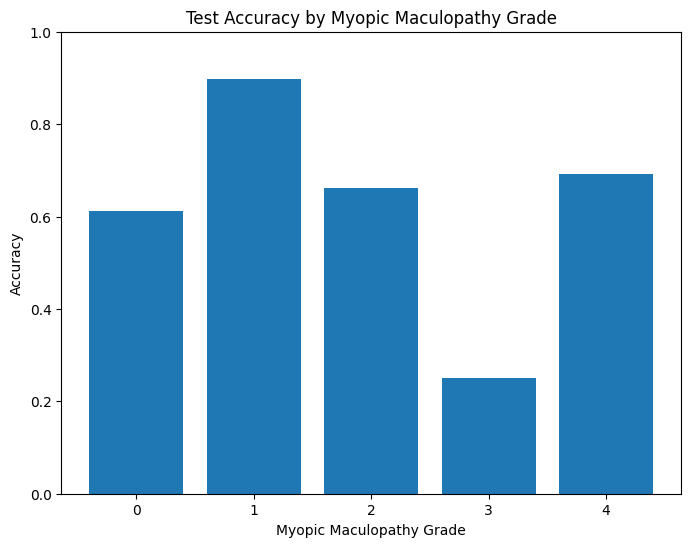

In [17]:
# bar chart of test accuracy by grade:
plt.figure(figsize=(8, 6))
plt.bar(range(5), grade_test_accuracies)
plt.title("Test Accuracy by Myopic Maculopathy Grade")
plt.xlabel("Myopic Maculopathy Grade")
plt.ylabel("Accuracy")
plt.xticks(range(5))
plt.ylim(0, 1)
plt.show()

# Class-imbalance resilient CNN for classification

In [18]:
# now we need to address class imbalance
# we can use class weights in the loss function to give more importance to the minority classes (grades 0 and 4)
class_counts = train_df["myopic_maculopathy_grade"].value_counts().sort_index()
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum() * len(class_counts) # normalise to number of classes
class_weights = torch.tensor(class_weights.values, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

# set up model and optimser as before:
model_class_imbalance = models.resnet18(pretrained=True) # load pretrained ResNet
# modify the final layer to output 5 classes (grades 0-4)
num_ftrs = model_class_imbalance.fc.in_features
model_class_imbalance.fc = nn.Linear(num_ftrs, 5)
model_class_imbalance = model_class_imbalance.to(device)
optimizer = optim.Adam(model_class_imbalance.parameters(), lr=0.001)

# set up dataloader as before:
dataset_class_imbalance = MyopicMaculopathyDataset(csv_file=train_csv, images_folder=train_images_folder, transform=transform)
dataloader = DataLoader(dataset_class_imbalance, batch_size=32, shuffle=True)

# training loop with class weights
num_epochs = 24
# use tqdm to show progress bar:
for epoch in range(num_epochs):
    model_class_imbalance.train()
    running_loss = 0.0
    for images, labels in tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = images.to(device)
        labels = labels.to(device, dtype=torch.long)
        optimizer.zero_grad()
        outputs = model_class_imbalance(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    epoch_loss = running_loss / len(dataset_class_imbalance)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

# save the model:
torch.save(model_class_imbalance.state_dict(), "myopic_maculopathy_resnet18_class_weights.pth")

/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/24: 100%|██████████| 36/36 [00:14<00:00,  2.43it/s]


Epoch 1/24, Loss: 1.3657


Epoch 2/24: 100%|██████████| 36/36 [00:14<00:00,  2.51it/s]


Epoch 2/24, Loss: 0.9676


Epoch 3/24: 100%|██████████| 36/36 [00:14<00:00,  2.52it/s]


...

Epoch 22/24, Loss: 0.3353


Epoch 23/24: 100%|██████████| 36/36 [00:14<00:00,  2.50it/s]


Epoch 23/24, Loss: 0.3900


Epoch 24/24: 100%|██████████| 36/36 [00:14<00:00,  2.50it/s]

Epoch 24/24, Loss: 0.3793


In [19]:
# test on training data to see if we are overfitting:
model_class_imbalance.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device, dtype=torch.long)
        outputs = model_class_imbalance(images) # get model output
        _, preds = torch.max(outputs, 1) # get predicted class
        all_preds.extend(preds.cpu().numpy()) # add to list of predictions on cpu
        all_labels.extend(labels.cpu().numpy()) # add to list of true labels on cpu

# print accuracy for each myopic_maculopathy_grade:
for grade in range(5):
    grade_indices = [i for i, label in enumerate(all_labels) if label == grade] # get indices of samples with this grade
    grade_preds = [all_preds[i] for i in grade_indices] # get predictions for this grade
    grade_labels = [all_labels[i] for i in grade_indices] # get true labels for this grade
    accuracy = sum([1 for p, l in zip(grade_preds, grade_labels) if p == l]) / len(grade_labels) # calculate accuracy for this grade
    print(f"Grade {grade} Training Accuracy: {accuracy:.4f}")

Grade 0 Training Accuracy: 0.9777
Grade 1 Training Accuracy: 0.7791
Grade 2 Training Accuracy: 0.7411
Grade 3 Training Accuracy: 0.9833
Grade 4 Training Accuracy: 0.4186


In [20]:
# test on test set (Data/Testing/Testing_Images and Data/Testing/Testing_LabelDemographic.csv)
# make a test dataloader:
test_csv = "Data/Testing/Testing_LabelDemographic.csv"
test_images_folder = "Data/Testing/Testing_Images"
test_dataset = MyopicMaculopathyDataset(csv_file=test_csv, images_folder=test_images_folder, transform=transform)
test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# test on all test data and calculate accuracy by class:
model_class_imbalance.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(device)
        labels = labels.to(device, dtype=torch.long)
        outputs = model_class_imbalance(images) # get model output
        _, preds = torch.max(outputs, 1) # get predicted class
        all_preds.extend(preds.cpu().numpy()) # add to list of predictions on cpu
        all_labels.extend(labels.cpu().numpy()) # add to list of true labels on cpu

# print accuracy for each myopic_maculopathy_grade:
grade_test_accuracies = [] # store accuracies
for grade in range(5):
    grade_indices = [i for i, label in enumerate(all_labels) if label == grade] # get indices of samples with this grade
    grade_preds = [all_preds[i] for i in grade_indices] # get predictions for this grade
    grade_labels = [all_labels[i] for i in grade_indices] # get true labels for this grade
    accuracy = sum([1 for p, l in zip(grade_preds, grade_labels) if p == l]) / len(grade_labels) # calculate accuracy for this grade
    grade_test_accuracies.append(accuracy)

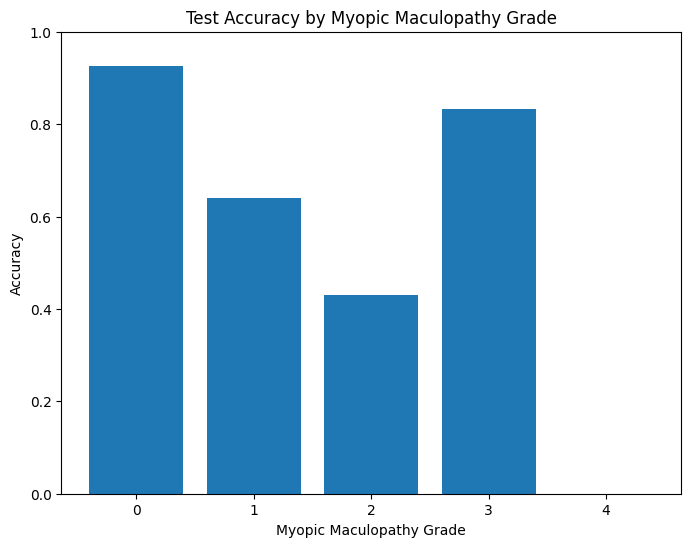

In [21]:
# bar chart of test accuracy by grade:
plt.figure(figsize=(8, 6))
plt.bar(range(5), grade_test_accuracies)
plt.title("Test Accuracy by Myopic Maculopathy Grade")
plt.xlabel("Myopic Maculopathy Grade")
plt.ylabel("Accuracy")
plt.xticks(range(5))
plt.ylim(0, 1)
plt.show()

# Loss function specific class imbalance

In [23]:
# we can also use a specific loss function for imbalanced data, such as focal loss, which gives more weight to hard-to-classify samples.

import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0, reduction="mean"):
        super().__init__()
        self.alpha = alpha  # tensor of per-class weights or None
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, inputs, targets):
        # per-sample cross-entropy
        ce_loss = F.cross_entropy(inputs, targets, reduction="none")
        pt = torch.exp(-ce_loss)  # pt = predicted probability of true class
        focal_loss = (1 - pt) ** self.gamma * ce_loss

        # apply class weights per sample if provided
        if self.alpha is not None:
            alpha = self.alpha.to(inputs.device)
            focal_loss = alpha[targets] * focal_loss

        if self.reduction == "mean":
            return focal_loss.mean()
        if self.reduction == "sum":
            return focal_loss.sum()
        return focal_loss

# use focal loss in training loop
criterion_focal = FocalLoss(alpha=class_weights, gamma=2.0)

# training loop with focal loss
model_focal_loss = models.resnet18(pretrained=True)  # load pretrained ResNet
num_ftrs = model_focal_loss.fc.in_features
model_focal_loss.fc = nn.Linear(num_ftrs, 5)
model_focal_loss = model_focal_loss.to(device)
optimizer = optim.Adam(model_focal_loss.parameters(), lr=0.001)

num_epochs = 24
for epoch in range(num_epochs):
    model_focal_loss.train()
    running_loss = 0.0
    for images, labels in tqdm(dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        images = images.to(device)
        labels = labels.to(device, dtype=torch.long)
        optimizer.zero_grad()
        outputs = model_focal_loss(images)
        loss = criterion_focal(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
    epoch_loss = running_loss / len(dataloader.dataset)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {epoch_loss:.4f}")

# save the model
torch.save(model_focal_loss.state_dict(), "myopic_maculopathy_resnet18_focal_loss.pth")

/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/thomashuitema/Downloads/patientpositioning-emsimtools-4ae16026d1ac/MPHY0050/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Epoch 1/24: 100%|██████████| 36/36 [00:15<00:00,  2.29it/s]


Epoch 1/24, Loss: 0.3103


Epoch 2/24: 100%|██████████| 36/36 [00:14<00:00,  2.55it/s]


Epoch 2/24, Loss: 0.2199


Epoch 3/24: 100%|██████████| 36/36 [00:13<00:00,  2.61it/s]


...

Epoch 22/24, Loss: 0.0901


Epoch 23/24: 100%|██████████| 36/36 [00:14<00:00,  2.48it/s]


Epoch 23/24, Loss: 0.0846


Epoch 24/24: 100%|██████████| 36/36 [00:14<00:00,  2.48it/s]

Epoch 24/24, Loss: 0.0972


Grade 0 Training Accuracy: 0.9406
Grade 1 Training Accuracy: 0.8228
Grade 2 Training Accuracy: 0.7589
Grade 3 Training Accuracy: 0.9167
Grade 4 Training Accuracy: 0.9302


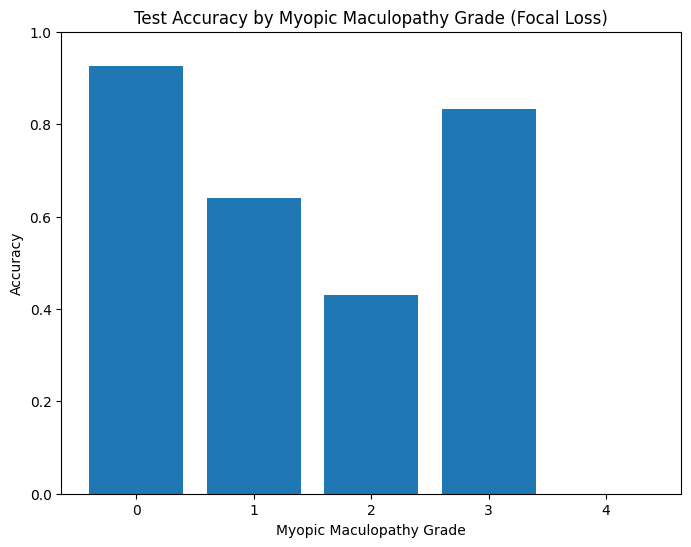

In [27]:
# evaluate focal loss model on training set as before:
model_focal_loss.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device, dtype=torch.long)
        outputs = model_focal_loss(images)  # get model output
        _, preds = torch.max(outputs, 1)  # get predicted class
        all_preds.extend(preds.cpu().numpy())  # add to list of predictions on cpu
        all_labels.extend(labels.cpu().numpy())  # add to list of true labels on cpu

grade_train_accuracies = []  # store accuracies
for grade in range(5):  
    grade_indices = [i for i, label in enumerate(all_labels) if label == grade]  # get indices of samples with this grade
    grade_preds = [all_preds[i] for i in grade_indices]  # get predictions for this grade
    grade_labels = [all_labels[i] for i in grade_indices]  # get true labels for this grade
    accuracy = sum([1 for p, l in zip(grade_preds, grade_labels) if p == l]) / len(grade_labels)  # calculate accuracy for this grade
    grade_train_accuracies.append(accuracy)
    print(f"Grade {grade} Training Accuracy: {accuracy:.4f}")

plt.figure(figsize=(8, 6))
plt.bar(range(5), grade_test_accuracies)
plt.title("Test Accuracy by Myopic Maculopathy Grade (Focal Loss)")
plt.xlabel("Myopic Maculopathy Grade")
plt.ylabel("Accuracy")
plt.xticks(range(5))
plt.ylim(0, 1)
plt.show()

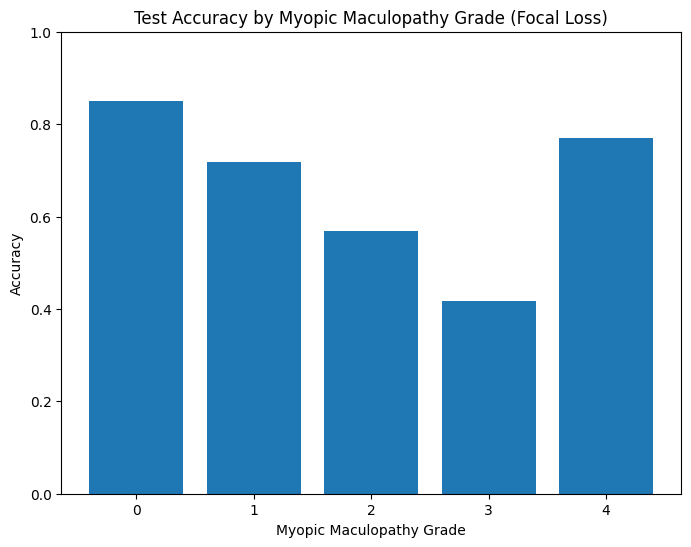

In [29]:
# evaluate focal loss model on test set, and plot test accuracy by grade as before:
model_focal_loss.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_dataloader:
        images = images.to(device)
        labels = labels.to(device, dtype=torch.long)
        outputs = model_focal_loss(images)  # get model output
        _, preds = torch.max(outputs, 1)  # get predicted class
        all_preds.extend(preds.cpu().numpy())  # add to list of predictions on cpu
        all_labels.extend(labels.cpu().numpy())  # add to list of true labels on cpu
grade_test_accuracies_focal = []  # store accuracies
for grade in range(5): 
    grade_indices = [i for i, label in enumerate(all_labels) if label == grade]  # get indices of samples with this grade
    grade_preds = [all_preds[i] for i in grade_indices]  # get predictions for this grade
    grade_labels = [all_labels[i] for i in grade_indices]  # get true labels for this grade
    accuracy = sum([1 for p, l in zip(grade_preds, grade_labels) if p == l]) / len(grade_labels)  # calculate accuracy for this grade
    grade_test_accuracies_focal.append(accuracy)
plt.figure(figsize=(8, 6))
plt.bar(range(5), grade_test_accuracies_focal)
plt.title("Test Accuracy by Myopic Maculopathy Grade (Focal Loss)")
plt.xlabel("Myopic Maculopathy Grade")
plt.ylabel("Accuracy")
plt.xticks(range(5))
plt.ylim(0, 1)
plt.show()